### Extrinsic Method - Random Forest - XXX bootstrap iterations

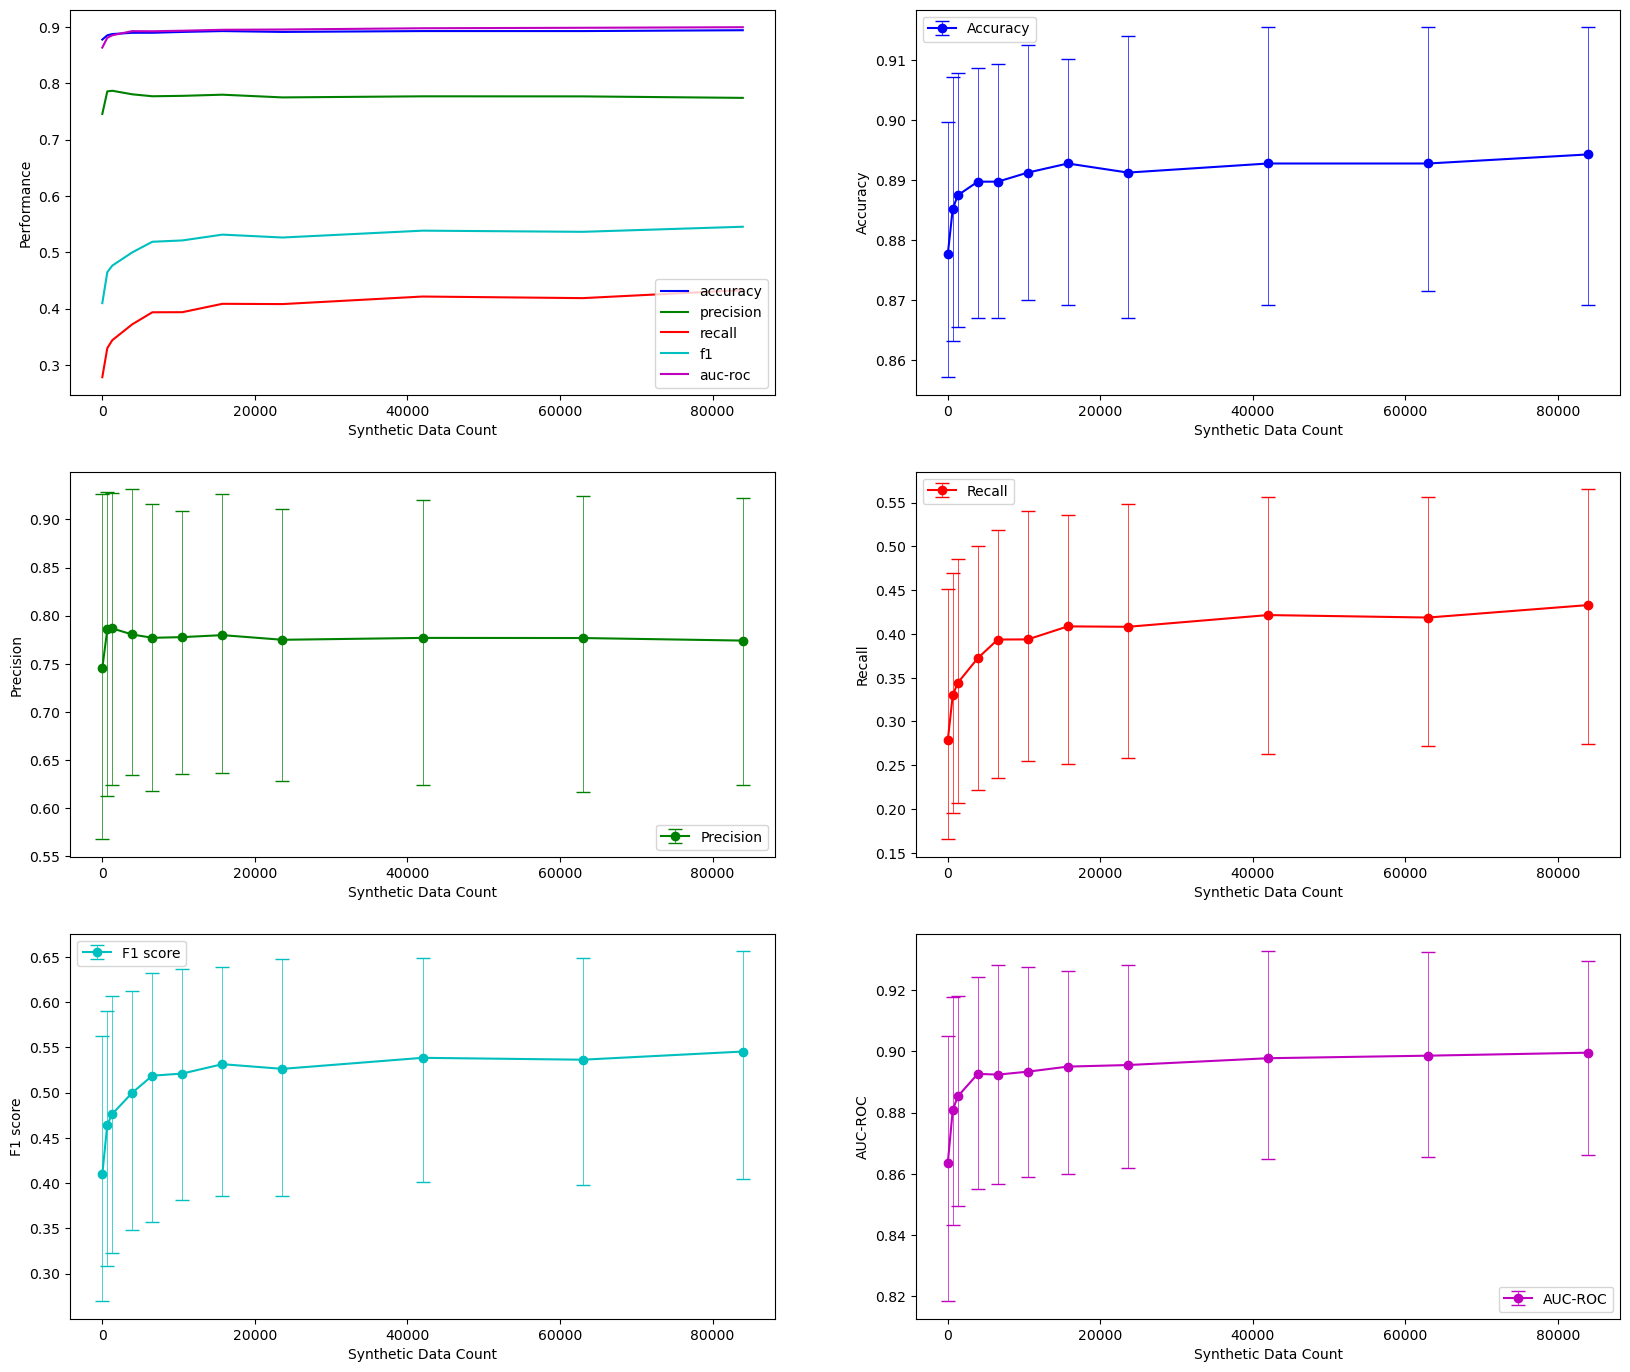

In [1]:
#Stacked Results
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#extrinsic_rf_bootstrap_vals = pd.read_excel('extrinsic_randomforest_bootstraps.xlsx')
extrinsic_rf_bootstrap_vals = pd.read_excel('extrinisc 15 300.xlsx')

# Create a 3x2 grid of subplots
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(20,17))  # adjust the size as needed

# Flatten the axes for easier indexing
axes = axes.flatten()

# Calculate average of performance metrics
median_metrics_rf = extrinsic_rf_bootstrap_vals.groupby('syn_size').median().reset_index()
metrics_labels = ['Accuracy', 'Precision', 'Recall', 'F1 score', 'AUC-ROC']
colors = ['b', 'g', 'r', 'c', 'm']
metrics_list = ['accuracy', 'precision', 'recall', 'f1', 'auc-roc']

# Calculate percentiles
lower_bound = extrinsic_rf_bootstrap_vals.groupby('syn_size').apply(lambda x: x.drop('syn_size', axis=1).quantile(0.025)).reset_index()
upper_bound = extrinsic_rf_bootstrap_vals.groupby('syn_size').apply(lambda x: x.drop('syn_size', axis=1).quantile(0.975)).reset_index()
median_metrics = extrinsic_rf_bootstrap_vals.groupby('syn_size').median().reset_index()

# Plotting the graph on the first axis
for i, metric in enumerate(metrics_list):
    axes[0].plot(median_metrics_rf['syn_size'], median_metrics_rf[metric], color=colors[i], label=metric)
axes[0].set_xlabel('Synthetic Data Count')
axes[0].set_ylabel('Performance')
axes[0].legend(loc='best')

# Move to the next axes for the error bars
for i, metric in enumerate(metrics_list):
    ax = axes[i+1]  # pick the current axis, starting from the second one

    ax.errorbar(median_metrics_rf['syn_size'], median_metrics_rf[metric], 
                yerr=[median_metrics_rf[metric]-lower_bound[metric], upper_bound[metric]-median_metrics_rf[metric]], 
                fmt='o-', color=colors[i], label=metrics_labels[i], elinewidth=0.5, capsize=5)

    ax.set_xlabel('Synthetic Data Count')
    ax.set_ylabel(f'{metrics_labels[i]}')
    ax.legend(loc='best')

# Save the entire figure instead of individual plots
plt.savefig('extrinsicresultserrors15.png', bbox_inches='tight')

# Show the figure with all subplots
plt.show()


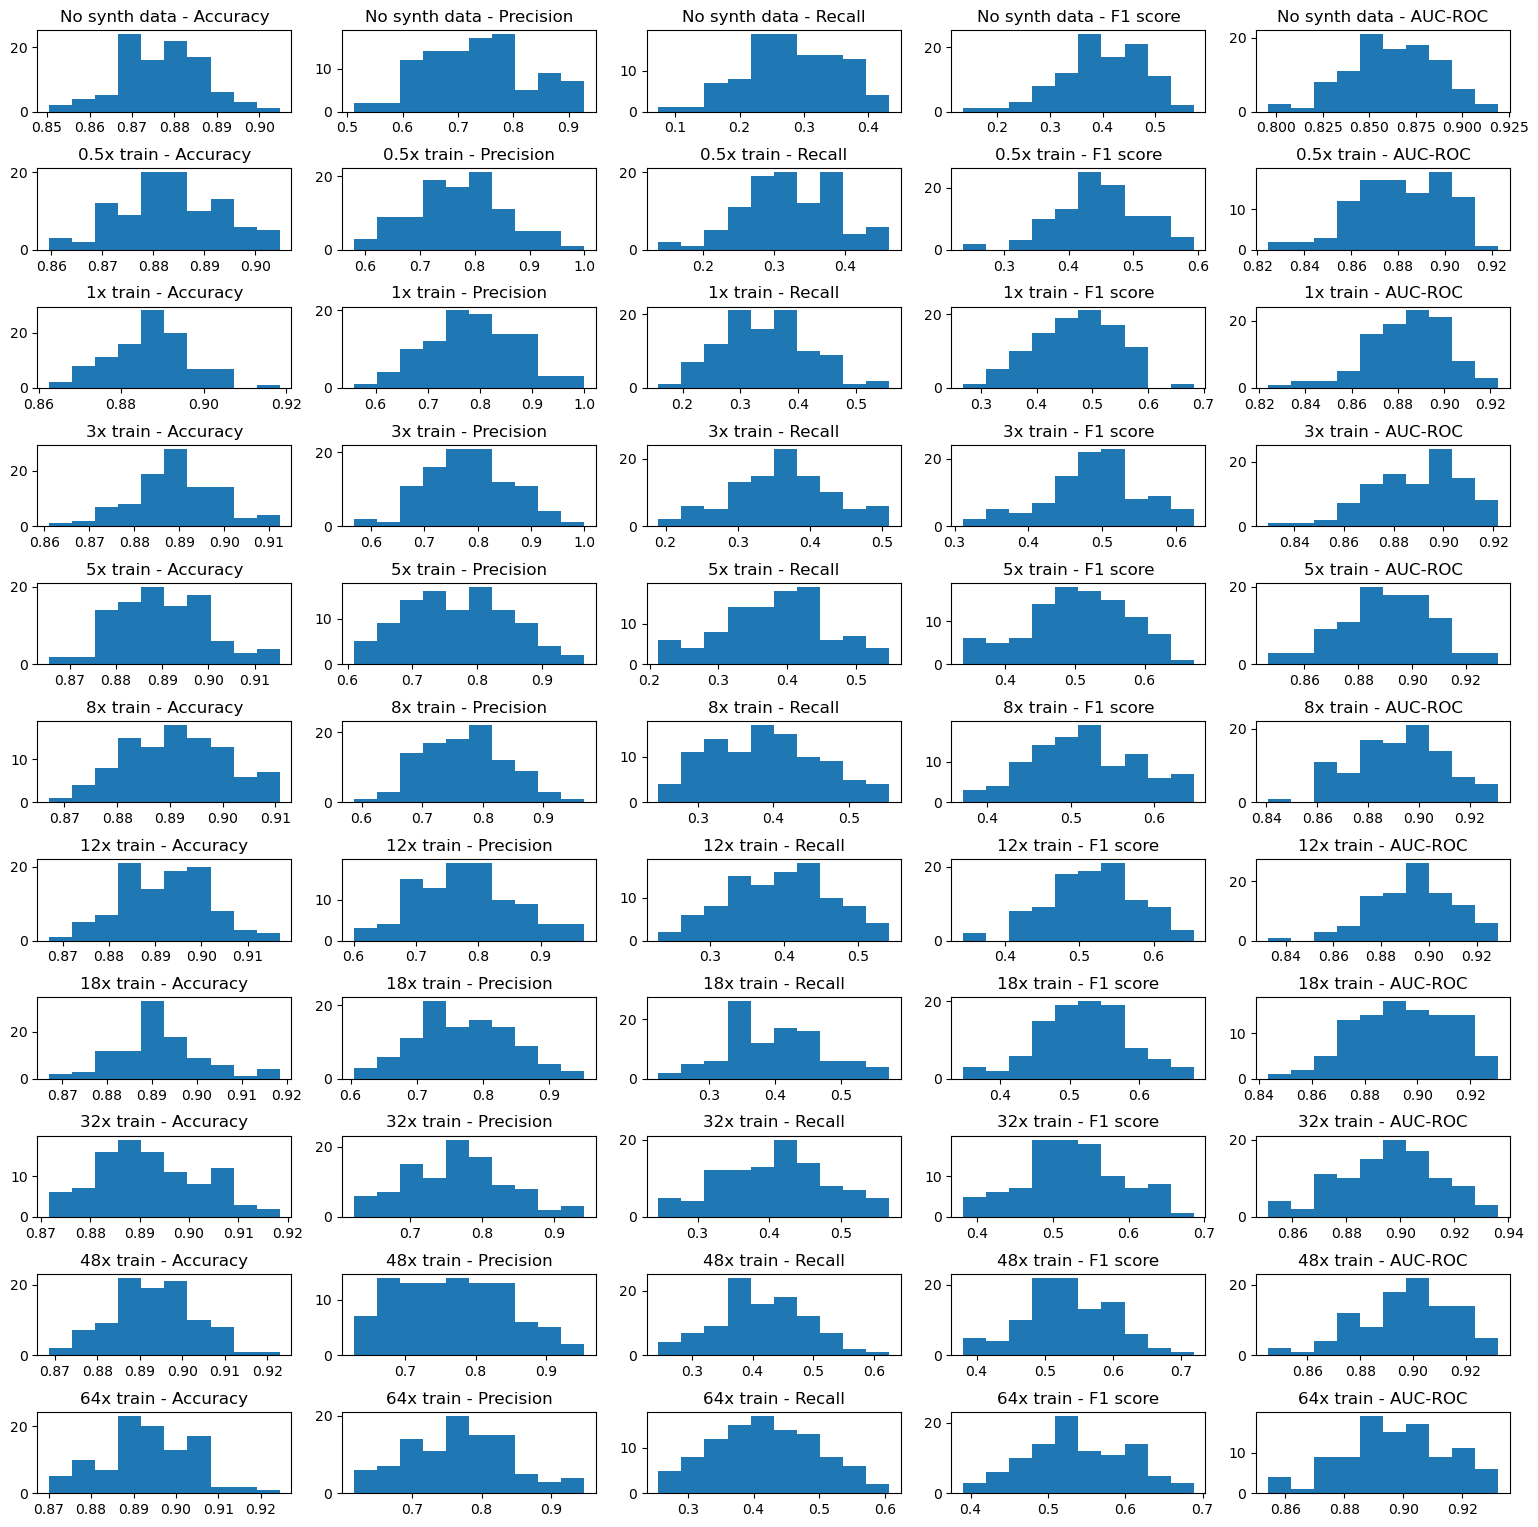

In [11]:
import matplotlib.pyplot as plt

countlen = 1311.975
syn_sizes = [1, 0.5*countlen, 1*countlen,  3935.92499999999,  5*countlen, 
            8*countlen, 15743.6999999999, 18*countlen, 32*countlen, 62974.7999999999, 64*countlen]
metrics = ['accuracy', 'precision', 'recall', 'f1', 'auc-roc']

#Labels for plots:
syn_sizes_labels = ['No synth data', '0.5x train' , '1x train' , '3x train' , '5x train' 
                    , '8x train' , '12x train' , '18x train' , '32x train', '48x train' , '64x train']
metrics_labels = ['Accuracy', 'Precision', 'Recall', 'F1 score', 'AUC-ROC']

fig, axs = plt.subplots(len(syn_sizes), len(metrics), figsize=(19,19))

grouped = extrinsic_rf_bootstrap_vals.groupby('syn_size')

for i, syn_size in enumerate(syn_sizes):
    group_df = grouped.get_group(syn_size).drop('syn_size', axis=1)
    for j, metric in enumerate(metrics):
        axs[i, j].hist(group_df[metric], bins=10)
        axs[i, j].set_title(f'{syn_sizes_labels[i]} - {metrics_labels[j]}')

plt.subplots_adjust(hspace=0.7)
plt.savefig('bootstrapdistextrinsic15.png',bbox_inches='tight')

plt.show()


In [12]:
median_metrics_rf = extrinsic_rf_bootstrap_vals.groupby('syn_size').median().reset_index()


In [14]:
median_metrics_rf

,syn_size,accuracy,precision,recall,f1,auc-roc
0,1.0000,0.876133,0.739936,0.278598,0.405805,0.862319
1,655.9875,0.883686,0.759630,0.316817,0.447511,0.880766
2,1311.9750,0.886707,0.783559,0.343444,0.473654,0.886203
3,3935.9250,0.888218,0.782971,0.361263,0.487518,0.892589
4,6559.8750,0.889728,0.769342,0.393231,0.511097,0.891321
5,10495.8000,0.890483,0.769231,0.388721,0.512709,0.892062
6,15743.7000,0.892749,0.776820,0.393924,0.523490,0.893453
7,23615.5500,0.891239,0.764171,0.395936,0.522044,0.894538
8,41983.2000,0.891239,0.767262,0.411793,0.527362,0.896370
9,62974.8000,0.892749,0.766667,0.414991,0.529576,0.900726
